# Field inference of a single (realistic) source with the Fast Multipole Method

This notebook calcuates the potential of a single source via the Fast Multipole Method in 2D (https://github.com/flatironinstitute/fmm2d) and serves as a benchmark for our novel method.

In [1]:
import numpy as np
import fmm2dpy as fmm
import matplotlib.pyplot as plt
import scienceplots  # noqa
import warnings

from hypermagnetics import plots
from hypermagnetics.sources import configure, configure_eval, _field_mt
from hypermagnetics.fmm_sources import potential2D

warnings.filterwarnings('ignore')
plt.style.use(["science", "ieee"])

## I. Target definition and data generation

The dipole field at $\mathbf{r}$ from a collection of point-like sources with moments $\mathbf{m}_i$ and positions $\mathbf{r}_i$ is computed via the scalar potential as $${\mu_0}\mathbf{H}_{\odot}(\mathbf{r}) = -\nabla\sum_{i=1}^N \underbrace{\overbrace{\frac{1}{2\pi |\mathbf{r}-\mathbf{r_i}|}}^{\text{Surface of 2D ball}}\overbrace{\frac{\mathbf{m}_i\cdot(\mathbf{r}-\mathbf{r_i})}{|\mathbf{r}-\mathbf{r_i}|}}^{\text{dipole term}}}_{\text{scalar potential }\psi_i}.$$

We generate random samples to serve as the training data, precomputing the target potential values. First, we describe the collection of sources.

In [2]:
# source_config = {
#     "shape": "sphere",
#     "n_samples": 1,
#     "lim": 100,
#     "res": 100,
#     "dim": 2,
#     "min_size": 0.25,
#     "max_size": 1,
#     "source_val": True,
#     "eps": 0,
# }
# train = configure_eval(**source_config, n_sources=4000, seed=0)
# plots(train, source=False)

# x_grid = np.array(train['grid'][:, 0].reshape((source_config["res"], source_config["res"])))
# y_grid = np.array(train['grid'][:, 1].reshape((source_config["res"], source_config["res"])))
# target_potential = train["potential_grid"][0 : 1].reshape((len(train["sources"][0 : 1]), source_config["res"], source_config["res"]))
# plt.contourf(x_grid, y_grid, target_potential[0])
# plt.colorbar()

## Code from FMM2D
https://github.com/flatironinstitute/fmm2d/blob/main/src/laplace/rfmm2d.f#L144
- 2D dipole vector is represented in complex form `dx + i*dy`
- Can then be more easily treated as directional derivatives of monopole (source) potentials
- negative sign in `ztmp` is conventional; **TODO** Check how FMM is using this in Green's function

```
do i = 1,ns
    do j = 1,nd
        ztmp = -(dipvec(j,1,i)+eye*dipvec(j,2,i))
        dipstr1(j,i) = dipstr(j,i)*ztmp
    enddo
enddo
```


In [3]:
# sim = train.copy()
# sim['potential_grid'], msp_sources = potential2D(sim['sources'], sim['grid'], "sphere")
# print(msp_sources)

# sim_potential = sim["potential_grid"][0 : 1].reshape((len(train["sources"][0 : 1]), source_config["res"], source_config["res"]))
# # plt.contourf(x_grid, y_grid, sim_potential[0])
# plt.contourf(x_grid, y_grid, np.clip(sim_potential[0] - target_potential[0], -0.5, 0.5))
# plt.colorbar()

# # if line:
# #     plt.plot(sim['grid'][:, 0], np.abs(sim["potential_grid"][0]))
# #     plt.plot(sim['grid'][:, 0], np.abs(train["potential_grid"][0]), color='red', linestyle='--')
# #     plt.yscale("log")

A realistic (non-pointlike) source will have, in two dimensions, the form $\mathbf{H}(\mathbf{r}) = - \mathbb{N}(\mathbf{r})\mathbf{M}$ inside the source, and by Gauss' Law $\mathbf{H} \sim \mathbf{H}_\odot$ outside it. The distinguishing feature of the dipole term is the $\sim 1/r$ dependence; higher multipole terms ($1/r^2$, $1/r^3$) might also be included, but the dipole term will quickly dominate at larger $r$.

In our simulation, we assume to have a ball of uniform magnetization. To achieve a solution via the FMM framework, we simply calculate the solutions of multiple pure (point-like) dipoles and we then set the inside of the magnet to the known constant value of $\frac{(r-r') \cdot \mathbf{m}}{2\pi R^2}$.

*Note: Magnets cannot overlap in this scenario.*

## Equivalent for prism

In [4]:
cfg_pr = {
    "n_samples": 1,
    "lim": 1,
    "res": 60,
    "shape": "prism",
    "line": True,
    "eps": 0,
    "quadtree": True,
}
train_pr = configure(**cfg_pr, n_sources=1, seed=0)

if not cfg_pr["line"]:
    x_grid_pr = np.array(train_pr['grid'][:, 0].reshape((cfg_pr["res"], cfg_pr["res"])))
    y_grid_pr = np.array(train_pr['grid'][:, 1].reshape((cfg_pr["res"], cfg_pr["res"])))
    target_msp = train_pr["potential_grid"][0 : 1].reshape((len(train_pr["sources"][0 : 1]), cfg_pr["res"], cfg_pr["res"]))
    target_field = train_pr["field_grid"][0, ..., 0].reshape((cfg_pr["res"], cfg_pr["res"]))
    # plt.contourf(x_grid_pr, y_grid_pr, target_msp[0])
    plt.contourf(x_grid_pr, y_grid_pr, target_field)
    plt.colorbar()
    plots(train_pr, shapes=True, field_bool=False)

Potential: 1.2100396
Field(x): 1.184232


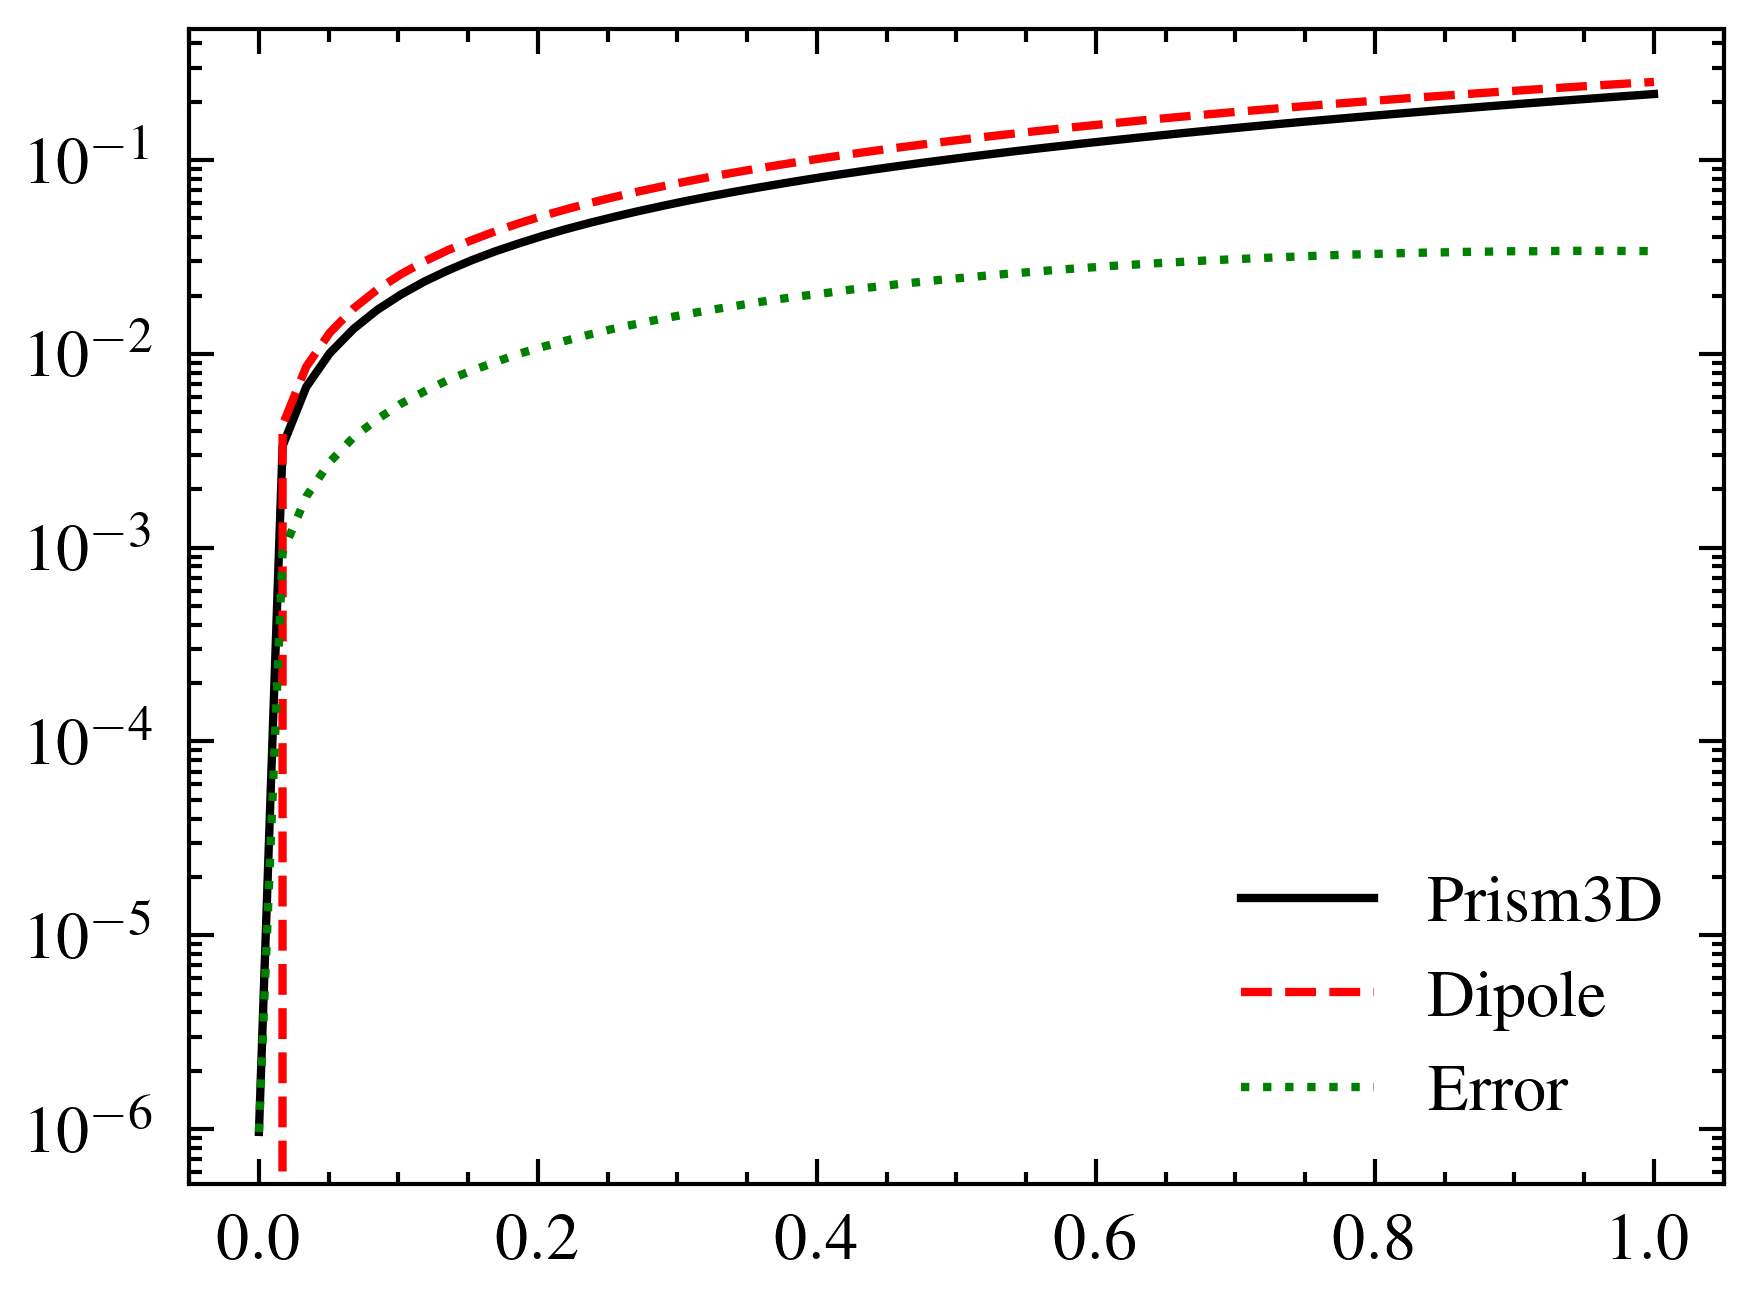

In [5]:
sim_pr = train_pr.copy()
sim_pr['potential_grid'], sim_pr['field_grid'] = potential2D(sim_pr['sources'], sim_pr['grid'], "prism")
sim_pr['field_grid_num'] = np.gradient(sim_pr['potential_grid'], cfg_pr["lim"]/cfg_pr["res"], axis=1)

if cfg_pr["line"]:
    # Only necessary for line plots
    plt.plot(train_pr['grid'][:, 0], np.abs(train_pr["potential_grid"][0]))
    plt.plot(sim_pr['grid'][:, 0], np.abs(sim_pr["potential_grid"][0]), color='red', linestyle='--')
    plt.plot(sim_pr['grid'][:, 0], np.abs(sim_pr["potential_grid"][0] - train_pr["potential_grid"][0]), color='green', linestyle=':')

    
    # plt.plot(train_pr['grid'][:, 0], np.abs(train_pr["field_grid"][0,...,0]))
    # plt.plot(sim_pr['grid'][:, 0], np.abs(sim_pr["field_grid_num"][0]), color='red', linestyle='--')
    # plt.plot(sim_pr['grid'][:, 0], np.abs(sim_pr["field_grid_num"][0] / train_pr["field_grid"][0,...,0]), color='green', linestyle=':')


    plt.yscale("log")
    # plt.xlim(5,15)
    plt.legend(["Prism3D", "Dipole", "Error"])

print("Potential:", np.nanmean(np.abs(sim_pr["potential_grid"][0] / train_pr["potential_grid"][0])))
print("Field(x):", np.nanmean(np.abs(sim_pr["field_grid_num"][0] / train_pr["field_grid"][0,...,0])))

## Validation of 3D implementaton for prism
2D magnetiziation in $xy$-plane and prism is elongated in $z$-direction.
Convert magnetic moment to magnetization: $M = m / (2 * a * 2 * b)$

0.9998717


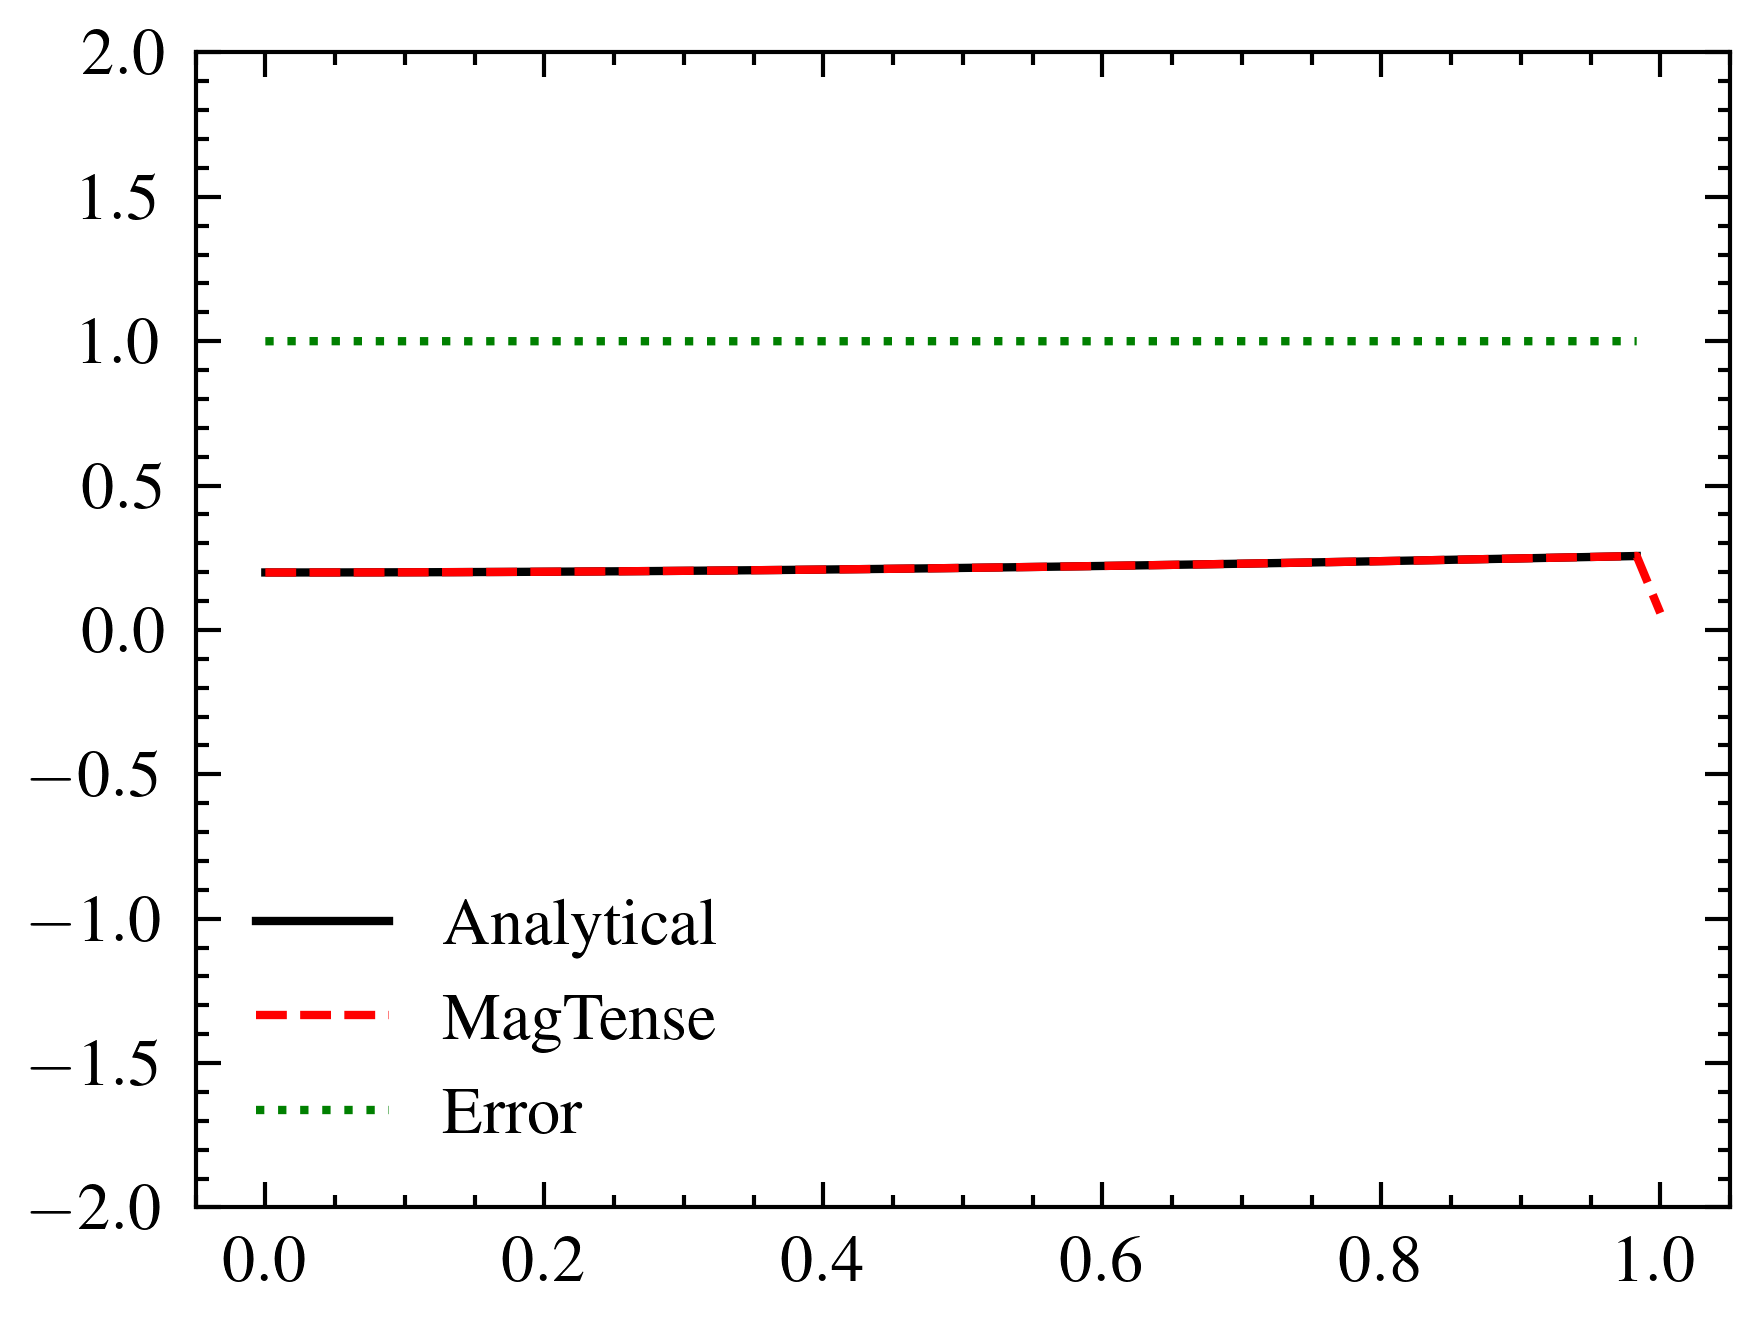

In [6]:
mt_sim, _ = _field_mt(train_pr['sources'], train_pr['grid'], "prism")

if cfg_pr["line"]:
    plt.plot(train_pr['grid'][:, 0], train_pr["field_grid"][0, ..., 0])
    plt.plot(train_pr['grid'][:, 0], mt_sim[0, ..., 0], color='red', linestyle='--')
    # plt.plot(train_pr['grid'][:, 0], train_pr["field_grid"][0, ..., 0], color='red', linestyle='--')
    plt.plot(train_pr['grid'][:, 0], mt_sim[0, ..., 0] / train_pr["field_grid"][0, ..., 0], color='green', linestyle=':')
    # plt.yscale("log")
    # plt.xlim(5,15)
    plt.ylim(-2, 2)
    plt.legend(["Analytical", "MagTense", "Error"])
    print(np.nanmean(np.abs(mt_sim[0, :, 0] / train_pr["field_grid"][0, :, 0])))

else:
    plt.contourf(x_grid_pr, y_grid_pr, np.clip(np.abs(
        mt_sim[0, ..., 0].reshape((cfg_pr["res"], cfg_pr["res"])) - target_field), 0, 1)
    )
    plt.colorbar()
    print(np.nanmean(np.abs(mt_sim[0, :, 0] / train_pr["field_grid"][0, :, 0])))